# Chatbot Implementation
This notebook highlights the **simplified steps** taken in implementing a Groq Chatbot in the application. These are the key steps:
1. Setting up the environment
2. Instantiate connection to tools
3. Instantiate connection to LLM
4. Build State Graph structure for orchestration
5. Invocation

## Step 1. Setting up the environment

In [89]:
import os
from dotenv import load_dotenv

load_dotenv()

# Set up Embedding model
OPENAI_EMB_MODEL = os.getenv("OPENAI_EMB_MODEL", "text-embedding-3-small")

# Set up LLM Config
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
GROQ_MODEL = os.getenv("GROQ_MODEL", "llama-3.1-8b-instant")

# Set up monitoring
LANGCHAIN_API_KEY = os.getenv("LANGCHAIN_API_KEY")
LANGCHAIN_TRACING_V2 = os.getenv("LANGCHAIN_API_KEY", "true")
LANGCHAIN_PROJECT = os.getenv("LANGCHAIN_PROJECT", "AI-Clinical-Assistant")

# Set up os environ
os.environ["LANGCHAIN_API_KEY"] = LANGCHAIN_API_KEY
os.environ["LANGCHAIN_TRACING_V2"] = LANGCHAIN_TRACING_V2
os.environ["LANGCHAIN_PROJECT"] = LANGCHAIN_PROJECT

## Step 2: Instantiate connection to Vector Stores and LLMs

In [90]:
# import re
# from langchain_community.document_loaders import WebBaseLoader
# from langchain_text_splitters import RecursiveCharacterTextSplitter
# from langchain_openai import OpenAIEmbeddings
# from langchain_community.vectorstores import FAISS

# def clean_text(text: str) -> str:
#     """
#     Cleans raw text from web pages:
#     - Collapses multiple newlines to max 2
#     - Removes excessive spaces and tabs
#     - Strips leading/trailing whitespace
#     """
#     text = re.sub(r"\n{3,}", "\n\n", text)        # Replace 3+ newlines with 2
#     text = re.sub(r"[ \t]+", " ", text)           # Replace multiple spaces/tabs with single space
#     return text.strip()

# def build_vector_store():
#     # Loading only from approved urls
#     urls = [
#         # Health Conditions
#         "https://www.healthhub.sg/health-conditions/acne",
#         "https://www.healthhub.sg/health-conditions/cold-sores",
#         "https://www.healthhub.sg/health-conditions/constipation",
#         "https://www.healthhub.sg/health-conditions/heart-arrhythmias",
#         "https://www.healthhub.sg/health-conditions/heart-failure-medication",
#         "https://www.healthhub.sg/health-conditions/coronary-artery-disease",
#         "https://www.healthhub.sg/health-conditions/heart-failure-basic-dietary-guideline",
#     ]

#     # Load from dedicated websites
#     loader = WebBaseLoader(urls)
#     documents = loader.load()

#     # Clean each document before splitting
#     for doc in documents:
#         doc.page_content = clean_text(doc.page_content)

#     # Set up splitter and obtain chunks
#     splitter = RecursiveCharacterTextSplitter(
#         chunk_size=1000,
#         chunk_overlap=200
#     )
#     chunks = splitter.split_documents(documents)

#     # Set up embeddings and vector store and return
#     embeddings = OpenAIEmbeddings(model=OPENAI_EMB_MODEL)
#     vectorstore = FAISS.from_documents(chunks, embeddings)
#     return vectorstore

# # Build and store vectorstore
# vectorstore = build_vector_store()
# vectorstore.save_local("faiss_index")

In [91]:
import json

from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# Simulate loading vector store
embeddings = OpenAIEmbeddings(model=OPENAI_EMB_MODEL)
vectorstore = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)

# Simulate usage of vector store
query = "What is Acne?"
docs = vectorstore.similarity_search(query, k=4)
for doc in docs:
    print(json.dumps({k: v for k, v in doc.model_dump().items() if k != "page_content"}, indent=4))
    print(f"Content: {doc.page_content.replace("\n", "\\n")}")

{
    "id": "c3aefbdc-d9a2-403b-880a-c20758270281",
    "metadata": {
        "source": "https://www.healthhub.sg/health-conditions/acne",
        "title": "Acne",
        "description": "Learn about symptoms and causes of acne, self help treatment options, medication and when to seek medical help.",
        "language": "en"
    },
    "type": "Document"
}
\n Management Tips\n\nWhat is Acne?\nAcne is a skin condition that occurs when sebum, an oil which is produced by your skin, along with dead skin cells clog your skin pores, creating whiteheads and blackheads. Bacteria on your skin can sometimes infect these acne spots and cause swelling and redness. The acne can develop into papules, pustules, nodules and cysts (refer to diagram below). It can occur on your face, chest or back.
{
    "id": "3f26ce20-cd44-4243-b7f7-1fc70c5a888c",
    "metadata": {
        "source": "https://www.healthhub.sg/health-conditions/acne",
        "title": "Acne",
        "description": "Learn about symptoms

In [92]:
from langchain_groq import ChatGroq

# Set up connection to Groq Client
llm_client = ChatGroq(
    api_key=GROQ_API_KEY,
    model=GROQ_MODEL,
    max_retries=2
)

## Step 3. Define node functions for usage in graph

In [93]:
from pydantic import BaseModel, ConfigDict, Field

# State Class to manage agent state
class State(BaseModel):
    """A base state object for a RAG Workflow."""

    # User Query
    user_query: str = Field(..., description="User Query")

    # LLM Output
    content: str = Field(default=None, description="LLM Response")

    # Sources
    sources: list[dict] = Field(default=[], description="List of Sources")

    # Usage Data
    usage: dict = Field(default={}, description="LLM Usage Data")

    model_config = ConfigDict(
        extra="ignore"
    )

In [94]:
# Simulate loading vector store
embeddings = OpenAIEmbeddings(model=OPENAI_EMB_MODEL)
vectorstore = FAISS.load_local(
    "faiss_index",
    embeddings,
    allow_dangerous_deserialization=True
)

# Node Definition to retrieve sources
def source_retrieval(state: State):
    docs = vectorstore.similarity_search(state.user_query, k=4)
    return {"sources": [doc.model_dump() for doc in docs]}

In [95]:
from langchain.messages import AIMessage

# Node Definition to synthesise response
async def synthesize(state: State):
    """
    Synthesizes a response based on the user query, conversation history and content from retrieved sources.

    Args:
        state: State that contains information about "user_query"
    
    Returns:
        state: Updated state containing the "content" and "usage"
    """
    try:
        # Combine all sources into one string
        sources_text = "\n\n".join(
            [f"Document {i+1}: {doc["page_content"]}" for i, doc in enumerate(state.sources)]
        )

        # Build the full prompt
        user_prompt = f"""
        You are a healthcare assistant, tasked with responding to user queries about healthcare matters.
        Given the following sources, answer the user query based ONLY on these sources.

        **Sources:**
        {sources_text}

        **User Query:** {state.user_query}
        Answer in less than 100 words.
        """

        # Call the LLM with the full prompt
        response: AIMessage = await llm_client.ainvoke(user_prompt)

        return {
            "content": response.content,
            "usage": getattr(response, "response_metadata", {})  # fallback if missing
        }

    except Exception as exc:
        print("Exception occurred: %s", exc)
        return {"content": str(exc), "usage": {}}

## Step 4: Build State Graph structure for orchestration

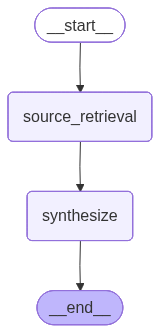

In [96]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

# Instantiate graph here
graph_builder = StateGraph(State)

# Include nodes
graph_builder.add_node("source_retrieval", source_retrieval)
graph_builder.add_node("synthesize", synthesize)

# Include Edges
graph_builder.add_edge(START, "source_retrieval")
graph_builder.add_edge("source_retrieval", "synthesize")
graph_builder.add_edge("synthesize", END)

# Compile and save graph
graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

## Step 5. Invocation

In [98]:
import json

response = await graph.ainvoke({"user_query": "What is Cold Sores?"})
print(json.dumps(response, indent=4))

{
    "user_query": "What is Cold Sores?",
    "content": "Cold sores are small fluid-filled blisters that usually appear on the lips or around the mouth. They are contagious from the moment symptoms such as tingling or itching appear and can spread via direct skin contact or exposure to the saliva of an infected person. Cold sores are caused by the Herpes Simplex Virus (HSV) and can be triggered by factors such as exposure to sunlight, stress, and weakened immune systems. They generally heal without leaving a scar.",
    "sources": [
        {
            "id": "5bdd7316-a46a-482b-82ac-6b2539b641f9",
            "metadata": {
                "source": "https://www.healthhub.sg/health-conditions/cold-sores",
                "title": "Cold Sores",
                "language": "en"
            },
            "page_content": "What are the possible causes of Cold Sores?\nCold sores are mostly caused by an infection with the Herpes Simplex Virus (HSV). Once infected with the HSV, the virus r